# Klasyfikacja Chorób Skóry - Projekt ML
*Dawid Kośka - 251171*

## 1. Setup & Dokumentacja Metadanych

### Informacje o zbiorze danych

| Właściwość | Wartość |
|------------|----------|
| **Nazwa** | DermNet |
| **Źródło** | [Kaggle - DermNet](https://www.kaggle.com/datasets/shubhamgoel27/dermnet) |
| **Licencja** | CC BY-NC-ND 4.0 |
| **Rozmiar oryginalny** | 19,500 obrazów, 23 klasy |
| **Rozmiar podzbioru** | 3 klasy, 100% zbioru |
| **Typ danych** | Obrazy RGB 2D, różne rozdzielczości |
| **Klasy docelowe** | Acne and Rosacea Photos, Eczema Photos, Psoriasis pictures Lichen Planus and related diseases |

### Przegląd literatury dla zbioru danych DermNet

W celu ewaluacji możliwości klasyfikacji chorób skóry (ze szczególnym uwzględnieniem łuszczycy, egzemy i trądziku) na bazie zbioru DermNet, przeanalizowano trzy recenzowane publikacje naukowe.

---

#### Publikacja 1: [Praca przeglądowa (IOP Conference Series, 2021)](https://iopscience.iop.org/article/10.1088/1757-899X/1076/1/012045/pdf)

*   **Zastosowana metoda:** Publikacja ta stanowi szczegółowy przegląd systematyczny metod uczenia maszynowego i głębokiego stosowanych w dermatologii. Autorzy zebrali i porównali wyniki wcześniejszych prac badawczych, które wykorzystywały zbiór DermNet do klasyfikacji wybranych schorzeń (takich jak trądzik, czy egzema). Analizowano głównie skuteczność architektur opartych na konwolucyjnych sieciach neuronowych.
*   **Raportowane metryki:**
    *   **Zadanie:** Klasyfikacja wieloklasowa (podzbiory DermNet obejmujące m.in. *Acne* i *Eczema*).
    *   **Uzyskane wyniki:** W analizowanych przez autorów badaniach opartych na bazach takich jak DermNet, zastosowanie zoptymalizowanych sieci CNN pozwoliło na osiągnięcie **Accuracy** w przedziale od **98.60% do 99.04%** dla wyselekcjonowanych klas (Ref [35] z powyższego linku).

---

#### Publikacja 2: [Hybrydowa architektura CNN-ViT (Scientific Reports, Nature, 2026)](https://www.nature.com/articles/s41598-026-35697-x)

*   **Zastosowana metoda:** W pracy zaproponowano zaawansowany system przeciwdziałający uprzedzeniom algorytmicznym (biasu) związanym z kolorem skóry pacjentów. Metodologia opiera się na dwuetapowym procesie:
    1.  **Segmentacja (unsupervised zero-shot):** Wyodrębnienie samej zmiany chorobowej ze zdjęcia bez użycia etykietowanych danych (odrzucenie tła i koloru zdrowszej skóry).
    2.  **Klasyfikacja - DermNet classifier:** Przekazanie wysegmentowanego obrazu do hybrydowej sieci łączącej model Vision Transformer (ViT) z tradycyjną siecią konwolucyjną (CNN).
*   **Raportowane metryki:**
    *   **Zadanie:** Pełna klasyfikacja wieloklasowa na zbiorze DermNet (uwzględniająca różnorodne odcienie skóry).
    *   **Validation Accuracy:** **ok. 81.00%** dla trudnego zadania klasyfikacji wieloklasowej po usunięciu wpływu koloru skóry.
    *   **IoU - Intersection over Union:** **90.00%** (jednolita skuteczność segmentacji zmiany chorobowej niezależnie od fototypu skóry pacjenta).

---

#### Publikacja 3: [Podejście wielofunkcyjne SDNet (Frontiers in Artificial Intelligence, 2026)](https://www.frontiersin.org/journals/artificial-intelligence/articles/10.3389/frai.2026.1732440/full)

*   **Zastosowana metoda:** Autorzy zaproponowali autorską sieć **SDNet** (Skin Disease Detection Network) wykorzystującą podejście dwutorowe (parallel-arm system) do ekstrakcji cech. Model wspierany jest przez metody wyjaśnialnej sztucznej inteligencji (XAI) w celu interpretacji decyzji sieci.
*   **Raportowane metryki:**
    *   **Zadanie:** Klasyfikacja 5 wybranych klas chorób skóry ze zbioru DermNet (w tym schorzeń bezpośrednio powiązanych z łuszczycą, egzemą, trądzikiem).
    *   **Dokładność (Accuracy):** **99.10%**
    *   **Czułość (Recall):** **99.10%**
    *   **Precyzja (Precision):** **98.96%**
    *   **F1-Score:** **98.95%**
    

**Podsumowanie**:

| Publikacja | Model | Accuracy | Inne raportowane metryki | Dodatkowe informacje |
| :--- | :--- | :--- | :--- | :--- |
| [IOP Conference Series, 2021](https://iopscience.iop.org/article/10.1088/1757-899X/1076/1/012045/pdf) | Zoptymalizowane sieci CNN (Ref [35]) | 98,60% - 99,04% | — | Praca o charakterze przeglądowym, porównująca skuteczność architektur CNN dla wyselekcjonowanych schorzeń skóry (m.in. trądzik, egzema). |
| [Scientific Reports, Nature, 2026](https://www.nature.com/articles/s41598-026-35697-x) | Hybrydowa sieć CNN-ViT z modułem segmentacji unsupervised zero-shot | ok. 81,00% (Validation) | IoU (segmentacja): 90,00% | Rozwiązanie zorientowane na redukcję uprzedzeń algorytmicznych (biasu) dotyczących koloru i fototypu skóry pacjenta. |
| [Frontiers in Artificial Intelligence, 2026](https://www.frontiersin.org/journals/artificial-intelligence/articles/10.3389/frai.2026.1732440/full) | SDNet (Skin Disease Detection Network) | 99,10% | • Recall: 99,10%<br>• Precision: 98,96%<br>• F1-Score: 98,95% | Autorski model oparty na systemie dwutorowym (parallel-arm) do ekstrakcji cech, klasyfikujący 5 klas chorób i wspierany metodami XAI. |


### Opis projektu

Projekt skupia się na klasyfikacji trzech typów chorób skóry przy użyciu klasycznych algorytmów uczenia maszynowego. Ze względu na ograniczenia sprzętowe, zbiór danych został zredukowany do 3 klas.

> Przy ładowaniu danych można zmienić stałą `SAMPLE_RATIO` na mniejsze - np. 25%  
> Zbiór był początkowo testowany na próbce 25%, lecz później zwiększono na pełen dataset.  
> W celu zmniejszenia czasu przetwarzania komórek w Jupyterze (ten notebook używa wyłącznie CPU), zaleca się zmniejszenie `SAMPLE RATIO`.  
> Na mojej maszynie przy pełnym datasecie cały processing notebooka trwał ~10 minut.

In [ ]:
# Importy bibliotek
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import warnings

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms

from torch.utils.data import DataLoader

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    f1_score, roc_auc_score, roc_curve, auc
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Używane urządzenie: {device}")

print("Biblioteki załadowane pomyślnie.")

Używane urządzenie: cpu
Biblioteki załadowane pomyślnie.


## 2. Eksploracyjna Analiza Danych (EDA) & Przetwarzanie Obrazów

### Ładowanie danych

Wybrane klasy:
- **Acne and Rosacea Photos** - zdjęcia trądziku i różowatości
- **Eczema Photos** - zdjęcia egzemy
- **Psoriasis pictures Lichen Planus and related diseases** - łuszczyca i choroby pokrewne

In [19]:
# Konfiguracja ścieżek i klas
TRAIN_DIR = '../data/dermnet/train/'
TEST_DIR = '../data/dermnet/test/'
IMG_SIZE = (224, 224)
SELECTED_CLASSES = [
    'Acne and Rosacea Photos',
    'Eczema Photos',
    'Psoriasis pictures Lichen Planus and related diseases'
]
# SAMPLE_RATIO = 0.25
SAMPLE_RATIO = 1.00

def load_images_from_folder(base_path, classes, sample_ratio=1.0):
    """Ładuje obrazy z wybranych klas i zwraca tablice numpy oraz etykiety."""
    images = []
    labels = []
    
    for class_name in classes:
        class_path = os.path.join(base_path, class_name)
        if not os.path.exists(class_path):
            print(f"Ostrzeżenie: Ścieżka {class_path} nie istnieje.")
            continue
        
        image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        # Próbkowanie
        n_samples = int(len(image_files) * sample_ratio)
        np.random.seed(42)
        sampled_files = np.random.choice(image_files, n_samples, replace=False)
        
        for img_file in sampled_files:
            img_path = os.path.join(class_path, img_file)
            try:
                img = Image.open(img_path).convert('RGB')
                img = img.resize(IMG_SIZE)
                img_array = np.array(img) / 255.0  # Normalizacja
                images.append(img_array)
                labels.append(class_name)
            except Exception as e:
                print(f"Błąd ładowania {img_path}: {e}")
    
    return np.array(images), np.array(labels)

# Ładowanie danych
print("Ładowanie danych treningowych...")
X_train_img, y_train = load_images_from_folder(TRAIN_DIR, SELECTED_CLASSES, SAMPLE_RATIO)
print(f"Załadowano {len(X_train_img)} obrazów treningowych.")

print("\nŁadowanie danych testowych...")
X_test_img, y_test = load_images_from_folder(TEST_DIR, SELECTED_CLASSES, SAMPLE_RATIO)
print(f"Załadowano {len(X_test_img)} obrazów testowych.")

Ładowanie danych treningowych...
Załadowano 3480 obrazów treningowych.

Ładowanie danych testowych...
Załadowano 973 obrazów testowych.


### Analiza rozkładu klas

Rozkład klas w zbiorze treningowym wykazuje **umiarkowane niezbalansowanie**:
- Psoriasis: 1405 próbek (40.4%)
- Eczema: 1235 próbek (35.4%)
- Acne: 840 próbek (24.2%)

Stosunek klasy dominującej do najmniej licznej wynosi ~1.67:1.
Aby zminimalizować wpływ niezbalansowania na wyniki, zastosowano:
- **Stratified K-Fold** — gwarantuje proporcjonalny podział klas w każdym foldzie.
- **`class_weight='balanced'`** — automatycznie zwiększa wagę klas mniejszościowych w funkcji kosztu.

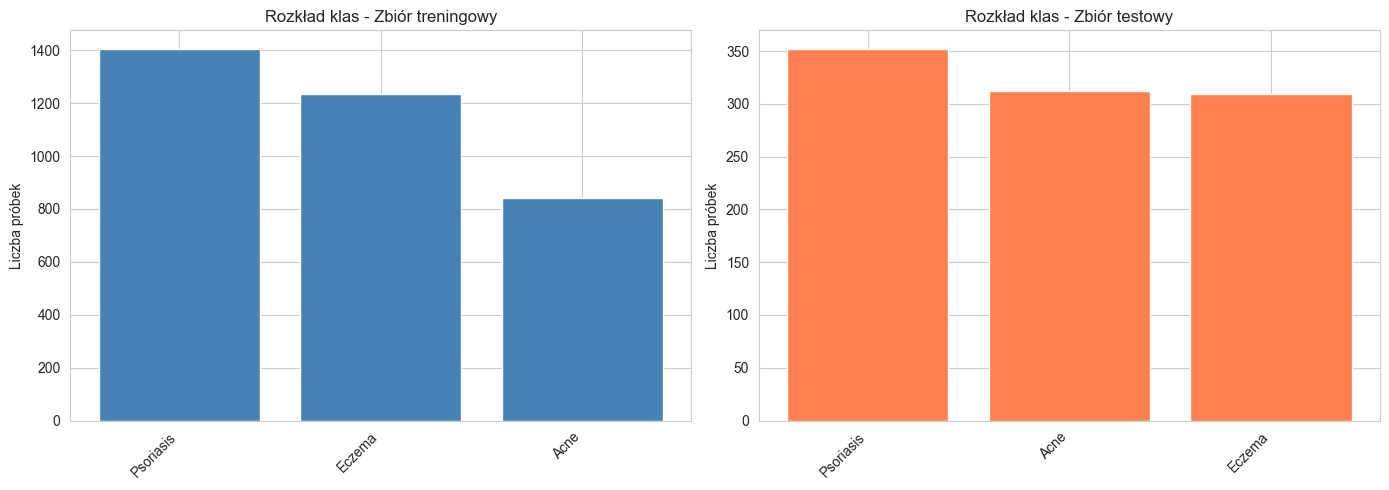


Treningowy:
Psoriasis pictures Lichen Planus and related diseases    1405
Eczema Photos                                            1235
Acne and Rosacea Photos                                   840
Name: count, dtype: int64

Testowy:
Psoriasis pictures Lichen Planus and related diseases    352
Acne and Rosacea Photos                                  312
Eczema Photos                                            309
Name: count, dtype: int64


In [20]:
# Rozkład klas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_counts = pd.Series(y_train).value_counts()
axes[0].bar(range(len(train_counts)), train_counts.values, color='steelblue')
axes[0].set_xticks(range(len(train_counts)))
axes[0].set_xticklabels([c.split()[0] for c in train_counts.index], rotation=45, ha='right')
axes[0].set_title('Rozkład klas - Zbiór treningowy')
axes[0].set_ylabel('Liczba próbek')

test_counts = pd.Series(y_test).value_counts()
axes[1].bar(range(len(test_counts)), test_counts.values, color='coral')
axes[1].set_xticks(range(len(test_counts)))
axes[1].set_xticklabels([c.split()[0] for c in test_counts.index], rotation=45, ha='right')
axes[1].set_title('Rozkład klas - Zbiór testowy')
axes[1].set_ylabel('Liczba próbek')

plt.tight_layout()
plt.show()

print(f"\nTreningowy:\n{train_counts}")
print(f"\nTestowy:\n{test_counts}")

### Wizualizacja przykładowych obrazów

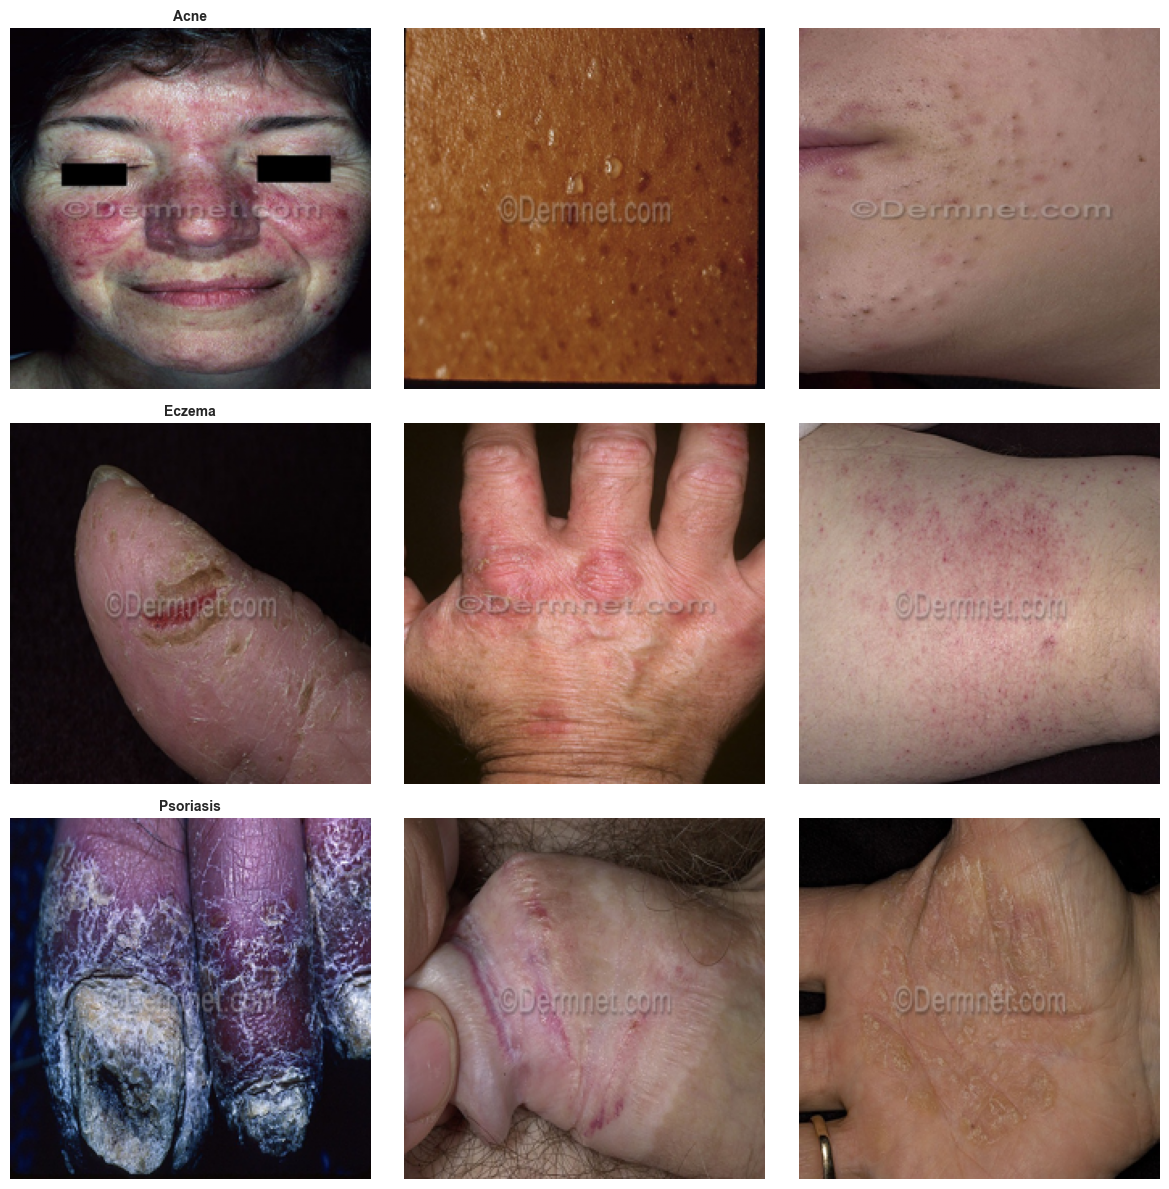

In [21]:
# Wizualizacja 3 przykładów z każdej klasy
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i, class_name in enumerate(SELECTED_CLASSES):
    class_indices = np.where(y_train == class_name)[0]
    sample_indices = np.random.choice(class_indices, 3, replace=False)
    
    for j, idx in enumerate(sample_indices):
        axes[i, j].imshow(X_train_img[idx])
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_title(class_name.split()[0], fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### Ekstrakcja cech

**Wybrana metoda:** Głębokie cechy semantyczne z pre-trenowanego ResNet18.

Zamiast surowych pikseli, używamy zamrożonego ResNet18 (trenowanego na ImageNet) do ekstrakcji 512-wymiarowych embeddingów. Forward pass przez sieć CNN dostarcza semantyczne cechy wysokiego poziomu, które znacznie lepiej reprezentują choroby skóry niż surowe piksele.

In [22]:
# Ładowanie pre-trenowanego ResNet18
print("Ładowanie ResNet18...")
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet.eval()  # Tryb ewaluacji (bez gradientów)
resnet = resnet.to(device)

# Usunięcie ostatniej warstwy FC (chcemy embeddingi)
feature_extractor = torch.nn.Sequential(*list(resnet.children())[:-1])
feature_extractor = feature_extractor.to(device)

# Transformacje dla ResNet (normalizacja ImageNet)
preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def extract_features(images):
    """Ekstrakcja cech z ResNet18 dla batch obrazów."""
    features = []
    with torch.no_grad():
        for img in images:
            img_tensor = preprocess(img).unsqueeze(0).float().to(device)
            feat = feature_extractor(img_tensor)
            features.append(feat.squeeze().cpu().numpy())
    return np.array(features)

# Ekstrakcja cech
print("Ekstrakcja cech treningowych...")
X_train = extract_features(X_train_img)
print("Ekstrakcja cech testowych...")
X_test = extract_features(X_test_img)

# Kodowanie etykiet
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print(f"\nKształt cech treningowych: {X_train.shape}")
print(f"Kształt cech testowych: {X_test.shape}")
print(f"Liczba wymiarów (embeddingi ResNet18): {X_train.shape[1]}")
print(f"\nMapowanie klas: {dict(enumerate(le.classes_))}")

Ładowanie ResNet18...
Ekstrakcja cech treningowych...
Ekstrakcja cech testowych...

Kształt cech treningowych: (3480, 512)
Kształt cech testowych: (973, 512)
Liczba wymiarów (embeddingi ResNet18): 512

Mapowanie klas: {0: np.str_('Acne and Rosacea Photos'), 1: np.str_('Eczema Photos'), 2: np.str_('Psoriasis pictures Lichen Planus and related diseases')}


## 3. Trening Modelu & Walidacja Krzyżowa

### Benchmarking modeli

Wybór modeli uzasadniono następująco:

- **LogisticRegression (L2)** — model liniowy stanowi naturalny baseline dla klasyfikacji na embeddingach CNN, które tworzą przestrzeń o strukturze liniowo-separowalnej. Regularyzacja L2 zapobiega overfittingowi w 512-wymiarowej przestrzeni cech. `class_weight='balanced'` kompensuje niezbalansowanie klas.

- **RandomForestClassifier** — ensemble drzew decyzyjnych modeluje nieliniowe granice decyzyjne, co może poprawić wyniki, gdy embeddingi ResNet nie są idealnie liniowo-separowalne. Parametr `class_weight='balanced'` kompensuje niezbalansowanie.

- **ResNet18 (fine-tuning)** — architektura residualna pre-trenowana na ImageNet. Fine-tuning ostatniego bloku (layer4) + warstwy FC adaptuje wysokopoziomowe cechy do specyfiki chorób skóry. Wybór ResNet18 (vs głębsze architektury) wynika z ograniczeń CPU.

Wybierzemy model z najlepszą wydajnością w 5-krotnej stratified walidacji krzyżowej (LR, RF) lub na hold-out validation set (ResNet18).

In [23]:
pipelines = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1, class_weight='balanced'))
    ]),
    'RandomForest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1, class_weight='balanced'))
    ])
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'roc_auc_ovr': 'roc_auc_ovr'}

cv_results = {}
for name, pipe in pipelines.items():
    print(f"Testowanie {name}...")
    scores = cross_validate(pipe, X_train, y_train_encoded, cv=skf, scoring=scoring, n_jobs=-1)
    cv_results[name] = scores
    
    acc = scores['test_accuracy']
    f1 = scores['test_f1_macro']
    roc_auc_ovr = scores['test_roc_auc_ovr']
    
    print(f"  Accuracy:  {acc.mean():.4f} ± {acc.std():.4f}")
    print(f"  F1 Macro:  {f1.mean():.4f} ± {f1.std():.4f}")
    print(f"  AUC (OvR): {roc_auc_ovr.mean():.4f} ± {roc_auc_ovr.std():.4f}")
    print(f"  Folds Acc: {[f'{s:.4f}' for s in acc]}\n")

# Wybór najlepszego modelu
best_model_name = max(cv_results, key=lambda k: cv_results[k]['test_accuracy'].mean())
best_model = pipelines[best_model_name]
cv_scores = cv_results[best_model_name]['test_accuracy']

print(f"\n{'='*60}")
print(f"Najlepszy model: {best_model_name}")
print(f"CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"{'='*60}")

Testowanie LogisticRegression...
  Accuracy:  0.6552 ± 0.0273
  F1 Macro:  0.6554 ± 0.0298
  AUC (OvR): 0.8216 ± 0.0196
  Folds Acc: ['0.6667', '0.6609', '0.6322', '0.6968', '0.6193']

Testowanie RandomForest...
  Accuracy:  0.6868 ± 0.0306
  F1 Macro:  0.6849 ± 0.0358
  AUC (OvR): 0.8540 ± 0.0242
  Folds Acc: ['0.6782', '0.6796', '0.6379', '0.7256', '0.7126']


Najlepszy model: RandomForest
CV Accuracy: 0.6868 ± 0.0306


### Hiperparameter tuning

W celu optymalizacji hiperparametrów modeli klasycznych, zastosowano `GridSearchCV` ze stratified 3-krotną walidacją krzyżową i metryką `f1_macro`. Przestrzenie wyszukiwania:
- **LogisticRegression**: `C` ∈ {0.01, 0.1, 1, 10}, `penalty` = 'l2'
- **RandomForest**: `n_estimators` ∈ {50, 100, 200}, `max_depth` ∈ {10, 20, None}

In [24]:
param_grid_lr = {
    'clf__C': [0.01, 0.1, 1, 10],
    'clf__penalty': ['l2']
}
param_grid_rf = {
    'clf__n_estimators': [50, 100, 200],
    'clf__max_depth': [10, 20, None]
}

tuned_lr = GridSearchCV(
    pipelines['LogisticRegression'], param_grid_lr,
    cv=StratifiedKFold(3, shuffle=True, random_state=42),
    scoring='f1_macro', n_jobs=-1
)
tuned_lr.fit(X_train, y_train_encoded)
print(f"Najlepsze parametry LR: {tuned_lr.best_params_}")
print(f"Najlepszy F1 macro (CV): {tuned_lr.best_score_:.4f}")

tuned_rf = GridSearchCV(
    pipelines['RandomForest'], param_grid_rf,
    cv=StratifiedKFold(3, shuffle=True, random_state=42),
    scoring='f1_macro', n_jobs=-1
)
tuned_rf.fit(X_train, y_train_encoded)
print(f"Najlepsze parametry RF: {tuned_rf.best_params_}")
print(f"Najlepszy F1 macro (CV): {tuned_rf.best_score_:.4f}")

Najlepsze parametry LR: {'clf__C': 0.01, 'clf__penalty': 'l2'}
Najlepszy F1 macro (CV): 0.6660
Najlepsze parametry RF: {'clf__max_depth': 10, 'clf__n_estimators': 200}
Najlepszy F1 macro (CV): 0.6701


### Fine-tuning ResNet18

Dodajemy pełny ResNet18 z fine-tuningiem ostatnich warstw (layer4 + fc) dla maksymalnej dokładności.

**Walidacja:** Ze względu na koszt obliczeniowy na CPU, zamiast 5-krotnej walidacji krzyżowej stosujemy stratified hold-out validation set (20% danych treningowych). Krzywe uczenia (Loss/Accuracy) są monitorowane w czasie treningu. Zaimplementowano **early stopping** — model z najniższym val_loss jest zachowywany jako ostateczny.

**Augmentacja danych:** Zastosowano podstawową augmentację na zbiorze treningowym: losowe odbicie poziome (50%), rotację o 90° (50%) i szum gaussowski (σ=0.02). Zbiór walidacyjny nie podlega augmentacji.

**Uwaga:** ResNet18 trenowany jest na 80% danych treningowych, podczas gdy modele klasyczne korzystają ze 100% próbek i walidacji krzyżowej.

**Kompensacja niezbalansowania klas:** Wagi klas w `CrossEntropyLoss` obliczane automatycznie przez `compute_class_weight('balanced')`.

Trening ResNet18 (5 epok) na urządzeniu: cpu...
  -> Nowy najlepszy model (val_loss: 0.6448)
Epoka 1/5 - Train Loss: 0.8550, Acc: 60.56% | Val Loss: 0.6448, Acc: 69.54%
Epoka 2/5 - Train Loss: 0.5629, Acc: 75.68% | Val Loss: 0.7103, Acc: 72.99%
  -> Nowy najlepszy model (val_loss: 0.6219)
Epoka 3/5 - Train Loss: 0.4803, Acc: 79.09% | Val Loss: 0.6219, Acc: 73.85%
  -> Nowy najlepszy model (val_loss: 0.5579)
Epoka 4/5 - Train Loss: 0.4488, Acc: 80.50% | Val Loss: 0.5579, Acc: 77.59%
  -> Nowy najlepszy model (val_loss: 0.5336)
Epoka 5/5 - Train Loss: 0.3494, Acc: 86.06% | Val Loss: 0.5336, Acc: 79.31%

Trening ResNet18 zakończony.


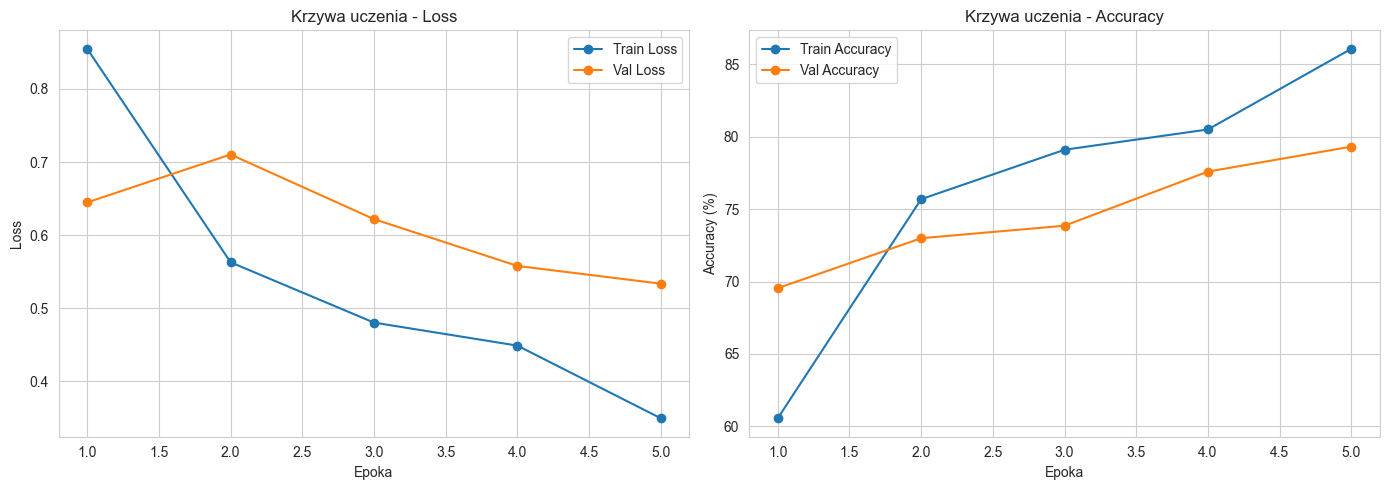

Wczytano najlepszy model (val_loss: 0.5336)

ResNet18 (fine-tuned) - Test Accuracy: 0.8129, F1 Macro: 0.8144, AUC OvR: 0.9338


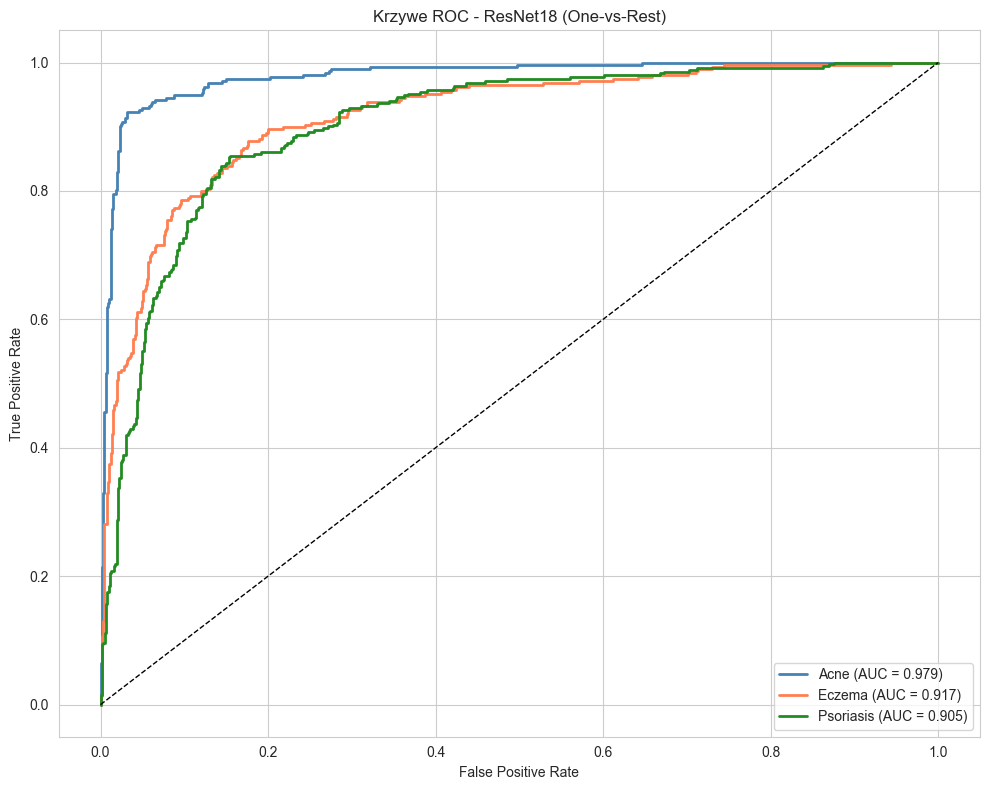

In [25]:
EPOCHS = 5

class AugmentedDataset(torch.utils.data.Dataset):
    def __init__(self, tensors, labels, augment=False):
        self.tensors = tensors
        self.labels = labels
        self.augment = augment

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.tensors[idx]
        label = self.labels[idx]
        if self.augment:
            if torch.rand(1) > 0.5:
                img = torch.flip(img, [2])
            if torch.rand(1) > 0.5:
                img = torch.rot90(img, k=1, dims=[1, 2])
            noise = torch.randn_like(img) * 0.02
            img = torch.clamp(img + noise, -2.5, 2.5)
        return img, label

# --- Model ---
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_features = resnet18.fc.in_features
resnet18.fc = nn.Linear(num_features, 3)

for param in resnet18.parameters():
    param.requires_grad = False
for param in resnet18.layer4.parameters():
    param.requires_grad = True
for param in resnet18.fc.parameters():
    param.requires_grad = True

resnet18 = resnet18.to(device)

# --- Class weights w CrossEntropyLoss ---
class_weights_arr = compute_class_weight(
    'balanced', classes=np.unique(y_train_encoded), y=y_train_encoded
)
class_weights_tensor = torch.FloatTensor(class_weights_arr).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, resnet18.parameters()), lr=0.001)

# --- Normalizacja ImageNet + podział train/val ---
imagenet_normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
)

X_all_tensor = torch.FloatTensor(X_train_img).permute(0, 3, 1, 2)
for i in range(X_all_tensor.shape[0]):
    X_all_tensor[i] = imagenet_normalize(X_all_tensor[i])
y_all_tensor = torch.LongTensor(y_train_encoded)

train_idx, val_idx = train_test_split(
    np.arange(len(y_train_encoded)), test_size=0.2,
    stratify=y_train_encoded, random_state=42
)

X_train_tensor_ft = X_all_tensor[train_idx]
y_train_tensor_ft = y_all_tensor[train_idx]
X_val_tensor = X_all_tensor[val_idx]
y_val_tensor = y_all_tensor[val_idx]

train_dataset = AugmentedDataset(X_train_tensor_ft, y_train_tensor_ft, augment=True)
val_dataset = AugmentedDataset(X_val_tensor, y_val_tensor, augment=False)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# --- Pętla treningowa z walidacją ---
train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_loss = float('inf')
best_model_state = None

print(f"Trening ResNet18 ({EPOCHS} epok) na urządzeniu: {device}...")
for epoch in range(EPOCHS):
    resnet18.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = resnet18(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    resnet18.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = resnet18(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    val_loss_epoch = val_loss / len(val_loader)
    
    if val_loss_epoch < best_val_loss:
        best_val_loss = val_loss_epoch
        best_model_state = {k: v.clone() for k, v in resnet18.state_dict().items()}
        print(f"  -> Nowy najlepszy model (val_loss: {val_loss_epoch:.4f})")

    val_acc = 100 * val_correct / val_total
    val_losses.append(val_loss_epoch)
    val_accs.append(val_acc)

    print(f"Epoka {epoch+1}/{EPOCHS} - "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss_epoch:.4f}, Acc: {val_acc:.2f}%")

print("\nTrening ResNet18 zakończony.")

# --- Krzywe uczenia ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(range(1, EPOCHS+1), train_losses, 'o-', label='Train Loss')
ax1.plot(range(1, EPOCHS+1), val_losses, 'o-', label='Val Loss')
ax1.set_xlabel('Epoka')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.set_title('Krzywa uczenia - Loss')

ax2.plot(range(1, EPOCHS+1), train_accs, 'o-', label='Train Accuracy')
ax2.plot(range(1, EPOCHS+1), val_accs, 'o-', label='Val Accuracy')
ax2.set_xlabel('Epoka')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.set_title('Krzywa uczenia - Accuracy')
plt.tight_layout()
plt.show()

if best_model_state is not None:
    resnet18.load_state_dict(best_model_state)
    print(f"Wczytano najlepszy model (val_loss: {best_val_loss:.4f})")

# --- Ewaluacja na test + krzywe ROC ---
X_test_tensor = torch.FloatTensor(X_test_img).permute(0, 3, 1, 2)
for i in range(X_test_tensor.shape[0]):
    X_test_tensor[i] = imagenet_normalize(X_test_tensor[i])
X_test_tensor = X_test_tensor.to(device)

resnet18.eval()
with torch.no_grad():
    outputs = resnet18(X_test_tensor)
    _, y_pred_resnet = torch.max(outputs, 1)
    y_pred_resnet = y_pred_resnet.cpu().numpy()
    y_pred_proba_resnet = torch.softmax(outputs, dim=1).cpu().numpy()

resnet_accuracy = accuracy_score(y_test_encoded, y_pred_resnet)
resnet_f1 = f1_score(y_test_encoded, y_pred_resnet, average='macro')
resnet_auc = roc_auc_score(y_test_encoded, y_pred_proba_resnet, multi_class='ovr', average='macro')

print(f"\nResNet18 (fine-tuned) - Test Accuracy: {resnet_accuracy:.4f}, "
      f"F1 Macro: {resnet_f1:.4f}, AUC OvR: {resnet_auc:.4f}")

# Krzywe ROC
y_test_bin = label_binarize(y_test_encoded, classes=[0, 1, 2])
colors_roc = ['steelblue', 'coral', 'forestgreen']

fig, ax = plt.subplots(figsize=(10, 8))
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba_resnet[:, i])
    roc_auc_i = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors_roc[i], lw=2,
            label=f'{le.classes_[i].split()[0]} (AUC = {roc_auc_i:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Krzywe ROC - ResNet18 (One-vs-Rest)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Porównanie wszystkich modeli

Ewaluacja modeli klasycznych na wydzielonym zbiorze testowym po hiperparameter tuningu. ResNet18 ewaluowany jest z checkpointu najlepszej epoki (najniższy val_loss).

In [37]:
lr_model = tuned_lr.best_estimator_
#lr_model.fit(X_train, y_train_encoded)
y_pred_lr = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)
lr_test_accuracy = accuracy_score(y_test_encoded, y_pred_lr)
lr_test_f1 = f1_score(y_test_encoded, y_pred_lr, average='macro')
lr_test_auc = roc_auc_score(y_test_encoded, lr_proba, multi_class='ovr', average='macro')

rf_model = tuned_rf.best_estimator_
#rf_model.fit(X_train, y_train_encoded)
y_pred_rf = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)
rf_test_accuracy = accuracy_score(y_test_encoded, y_pred_rf)
rf_test_f1 = f1_score(y_test_encoded, y_pred_rf, average='macro')
rf_test_auc = roc_auc_score(y_test_encoded, rf_proba, multi_class='ovr', average='macro')

# Porównanie wyników testowych (ResNet18 ewaluowany w Cell 13)
print("\n" + "="*70)
print("RZECZYWISTE DOKŁADNOŚCI NA ZBIORZE TESTOWYM (TEST ACCURACY)")
print("="*70)
print(f"LogisticRegression    - Test Accuracy: {lr_test_accuracy:.4f}")
print(f"RandomForest          - Test Accuracy: {rf_test_accuracy:.4f}")
print(f"ResNet18 (fine-tuned) - Test Accuracy: {resnet_accuracy:.4f}")
print("="*70)

test_accuracies = {
    'LogisticRegression': lr_test_accuracy,
    'RandomForest': rf_test_accuracy,
    'ResNet18': resnet_accuracy
}

best_model_name = max(test_accuracies, key=test_accuracies.get)

if best_model_name == 'ResNet18':
    print("\n🏆 Najlepszy model na zbiorze testowym: ResNet18 (fine-tuned)")
    y_pred = y_pred_resnet
    y_pred_proba = y_pred_proba_resnet
    accuracy = resnet_accuracy
    macro_f1 = resnet_f1
    roc_auc_ovr = resnet_auc
else:
    print(f"\n🏆 Najlepszy model na zbiorze testowym: {best_model_name}")
    y_pred = y_pred_lr if best_model_name == 'LogisticRegression' else y_pred_rf
    y_pred_proba = lr_proba if best_model_name == 'LogisticRegression' else rf_proba
    accuracy = test_accuracies[best_model_name]
    macro_f1 = lr_test_f1 if best_model_name == 'LogisticRegression' else rf_test_f1
    roc_auc_ovr = lr_test_auc if best_model_name == 'LogisticRegression' else rf_test_auc


RZECZYWISTE DOKŁADNOŚCI NA ZBIORZE TESTOWYM (TEST ACCURACY)
LogisticRegression    - Test Accuracy: 0.7297
RandomForest          - Test Accuracy: 0.7708
ResNet18 (fine-tuned) - Test Accuracy: 0.8129

🏆 Najlepszy model na zbiorze testowym: ResNet18 (fine-tuned)


## 4. Ewaluacja Modelu & Metryki Ilościowe

### Macierz pomyłek

Porównanie macierzy pomyłek dla wszystkich trzech modeli na zbiorze testowym

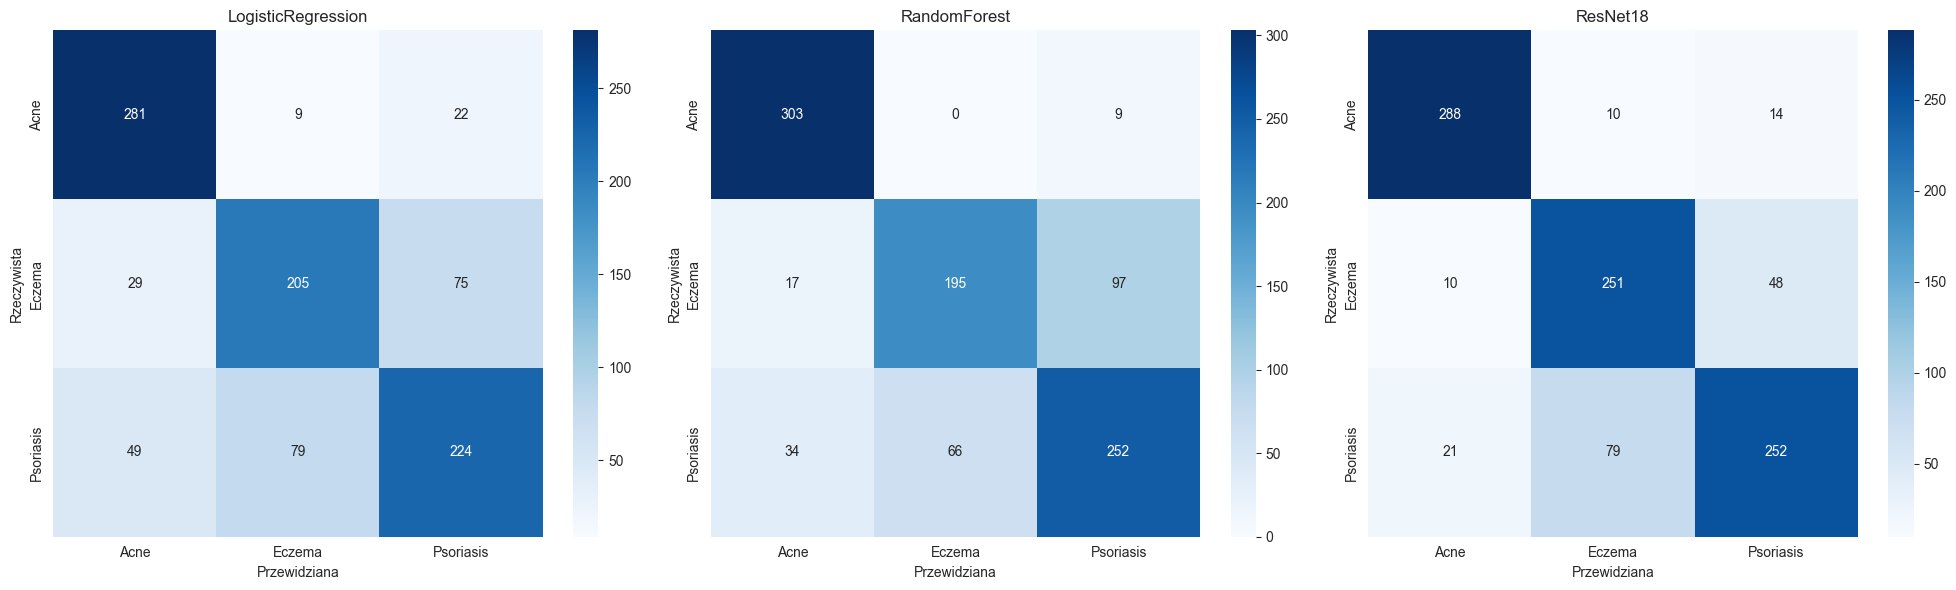

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
preds = {'LogisticRegression': y_pred_lr, 'RandomForest': y_pred_rf, 'ResNet18': y_pred_resnet}

for i, (name, pred) in enumerate(preds.items()):
    cm = confusion_matrix(y_test_encoded, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=[c.split()[0] for c in le.classes_],
                yticklabels=[c.split()[0] for c in le.classes_])
    axes[i].set_title(name)
    axes[i].set_ylabel('Rzeczywista')
    axes[i].set_xlabel('Przewidziana')
plt.tight_layout()
plt.show()

### Raport klasyfikacji

Szczegółowe metryki per klasa (precision, recall, F1-score) dla każdego modelu.

In [28]:
for name, pred in preds.items():
    print(f"\n--- {name} ---")
    print(classification_report(y_test_encoded, pred, target_names=le.classes_, digits=4))


--- LogisticRegression ---
                                                       precision    recall  f1-score   support

                              Acne and Rosacea Photos     0.7827    0.9006    0.8376       312
                                        Eczema Photos     0.6997    0.6634    0.6811       309
Psoriasis pictures Lichen Planus and related diseases     0.6978    0.6364    0.6657       352

                                             accuracy                         0.7297       973
                                            macro avg     0.7267    0.7335    0.7281       973
                                         weighted avg     0.7256    0.7297    0.7257       973


--- RandomForest ---
                                                       precision    recall  f1-score   support

                              Acne and Rosacea Photos     0.8559    0.9712    0.9099       312
                                        Eczema Photos     0.7471    0.6311    0.6842       

### Porównanie krzywych ROC

Krzywe ROC (micro-average) dla wszystkich modeli pozwalają ocenić zdolność dyskriminacyjną niezależnie od progu decyzyjnego. Im bliżej lewego górnego rogu, tym lepszy model.

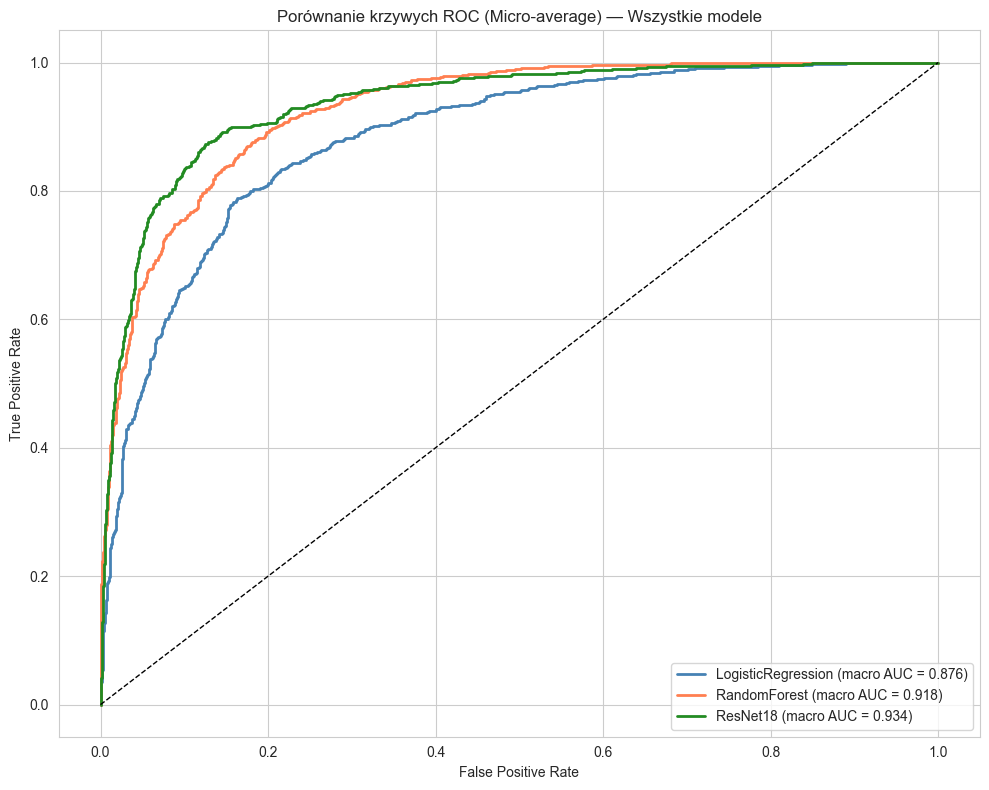

In [40]:
fig, ax = plt.subplots(figsize=(10, 8))

for name, proba, color in [
    ('LogisticRegression', lr_proba, 'steelblue'),
    ('RandomForest', rf_proba, 'coral'),
    ('ResNet18', y_pred_proba_resnet, 'forestgreen')
]:
    fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), proba.ravel())
    macro_auc = roc_auc_score(y_test_encoded, proba, multi_class='ovr', average='macro')
    ax.plot(fpr_micro, tpr_micro, color=color, lw=2,
            label=f'{name} (macro AUC = {macro_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Porównanie krzywych ROC (Micro-average) — Wszystkie modele')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Kluczowe metryki najlepszego modelu

Podsumowanie kluczowych metryk dla modelu o najwyższej dokładności na zbiorze testowym.

In [29]:
# Wyświetlanie kluczowych metryk
print("\n" + "="*70)
print("KLUCZOWE METRYKI WYDAJNOŚCI NA ZBIORZE TESTOWYM")
print("="*70)
print(f"Model:                              {best_model_name}")
print(f"Accuracy (dokładność):              {accuracy:.4f}")
print(f"Macro F1-Score:                     {macro_f1:.4f}")
print(f"ROC AUC (One-vs-Rest, macro):       {roc_auc_ovr:.4f}")
print("="*70)


KLUCZOWE METRYKI WYDAJNOŚCI NA ZBIORZE TESTOWYM
Model:                              ResNet18
Accuracy (dokładność):              0.8129
Macro F1-Score:                     0.8144
ROC AUC (One-vs-Rest, macro):       0.9338


### Tabela zbiorcza - porownanie modeli

Tabela ponizej jest generowana automatycznie na podstawie obliczonych wynikow.
Dla ResNet18 nie wykonano CV ze wzgledu na koszt obliczeniowy na CPU.

In [30]:
from IPython.display import display, Markdown

def format_mean_std(values):
    return f"{values.mean():.4f} ± {values.std():.4f}"

cv_acc_lr = cv_results['LogisticRegression']['test_accuracy']
cv_acc_rf = cv_results['RandomForest']['test_accuracy']

metrics_table = pd.DataFrame([
    {
        "Model": "Logistic Regression (L2)",
        "CV Accuracy (mean ± std)": format_mean_std(cv_acc_lr),
        "Test Accuracy": f"{lr_test_accuracy:.4f}",
        "Test F1 (macro)": f"{lr_test_f1:.4f}",
        "Test AUC (OvR)": f"{lr_test_auc:.4f}"
    },
    {
        "Model": "Random Forest",
        "CV Accuracy (mean ± std)": format_mean_std(cv_acc_rf),
        "Test Accuracy": f"{rf_test_accuracy:.4f}",
        "Test F1 (macro)": f"{rf_test_f1:.4f}",
        "Test AUC (OvR)": f"{rf_test_auc:.4f}"
    },
    {
        "Model": "ResNet18 (fine-tuned)",
        "CV Accuracy (mean ± std)": "-- (brak CV)",
        "Test Accuracy": f"{resnet_accuracy:.4f}",
        "Test F1 (macro)": f"{resnet_f1:.4f}",
        "Test AUC (OvR)": f"{resnet_auc:.4f}"
    }
])

display(metrics_table)
display(Markdown(metrics_table.to_markdown(index=False)))

,Model,CV Accuracy (mean ± std),Test Accuracy,Test F1 (macro),Test AUC (OvR)
0,Logistic Regression (L2),0.6552 ± 0.0273,0.7297,0.7281,0.8757
1,Random Forest,0.6868 ± 0.0306,0.7708,0.7680,0.9177
2,ResNet18 (fine-tuned),-- (brak CV),0.8129,0.8144,0.9338


| Model                    | CV Accuracy (mean ± std)   |   Test Accuracy |   Test F1 (macro) |   Test AUC (OvR) |
|:-------------------------|:---------------------------|----------------:|------------------:|-----------------:|
| Logistic Regression (L2) | 0.6552 ± 0.0273            |          0.7297 |            0.7281 |           0.8757 |
| Random Forest            | 0.6868 ± 0.0306            |          0.7708 |            0.768  |           0.9177 |
| ResNet18 (fine-tuned)    | -- (brak CV)               |          0.8129 |            0.8144 |           0.9338 |

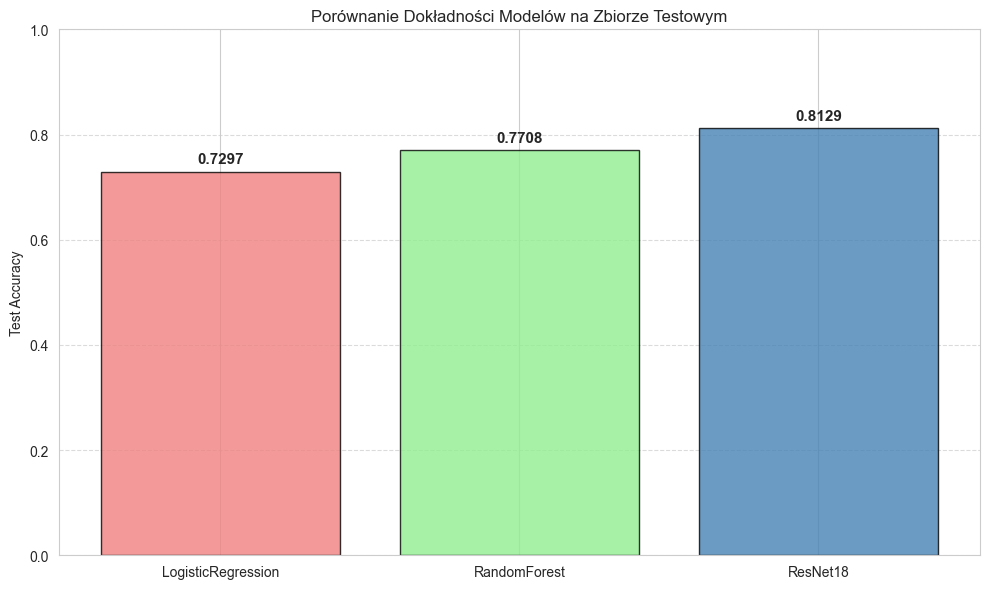

In [31]:
plt.figure(figsize=(10, 6))
colors = ['lightcoral', 'lightgreen', 'steelblue']
bars = plt.bar(test_accuracies.keys(), test_accuracies.values(), color=colors, alpha=0.8, edgecolor='black')

# Dodanie wartości nad słupkami
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.4f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylabel('Test Accuracy')
plt.title('Porównanie Dokładności Modelów na Zbiorze Testowym')
plt.ylim([0, 1.0])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Eksport wyników do CSV

Zapisujemy metryki i predykcje do plików CSV dla dalszej analizy.

In [42]:
# Eksport metryk
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Macro F1-Score', 'ROC AUC (OvR)', 'CV Mean', 'CV Std'],
    'Value': [accuracy, macro_f1, roc_auc_ovr, cv_scores.mean(), cv_scores.std()]
})
metrics_df.to_csv('../results/dawid_koska_dermnet_classification_metrics.csv', index=False)
print("Metryki zapisane do: dawid_koska_dermnet_classification_metrics.csv")

# Eksport predykcji
predictions_df = pd.DataFrame({
    'true_label': le.inverse_transform(y_test_encoded),
    'predicted_label': le.inverse_transform(y_pred),
    'prob_' + le.classes_[0].split()[0]: y_pred_proba[:, 0],
    'prob_' + le.classes_[1].split()[0]: y_pred_proba[:, 1],
    'prob_' + le.classes_[2].split()[0]: y_pred_proba[:, 2]
})
predictions_df.to_csv('../results/dawid_koska_dermnet_test_predictions.csv', index=False)
print("Predykcje zapisane do: dawid_koska_dermnet_test_predictions.csv")

Metryki zapisane do: dawid_koska_dermnet_classification_metrics.csv
Predykcje zapisane do: dawid_koska_dermnet_test_predictions.csv


### Grad-CAM — wizualizacja uwagi modelu

Grad-CAM (Gradient-weighted Class Activation Mapping) pokazuje, które regiony obrazu miały największy wpływ na predykcję modelu. Zielony tytuł = poprawna klasyfikacja, czerwony = błędna.

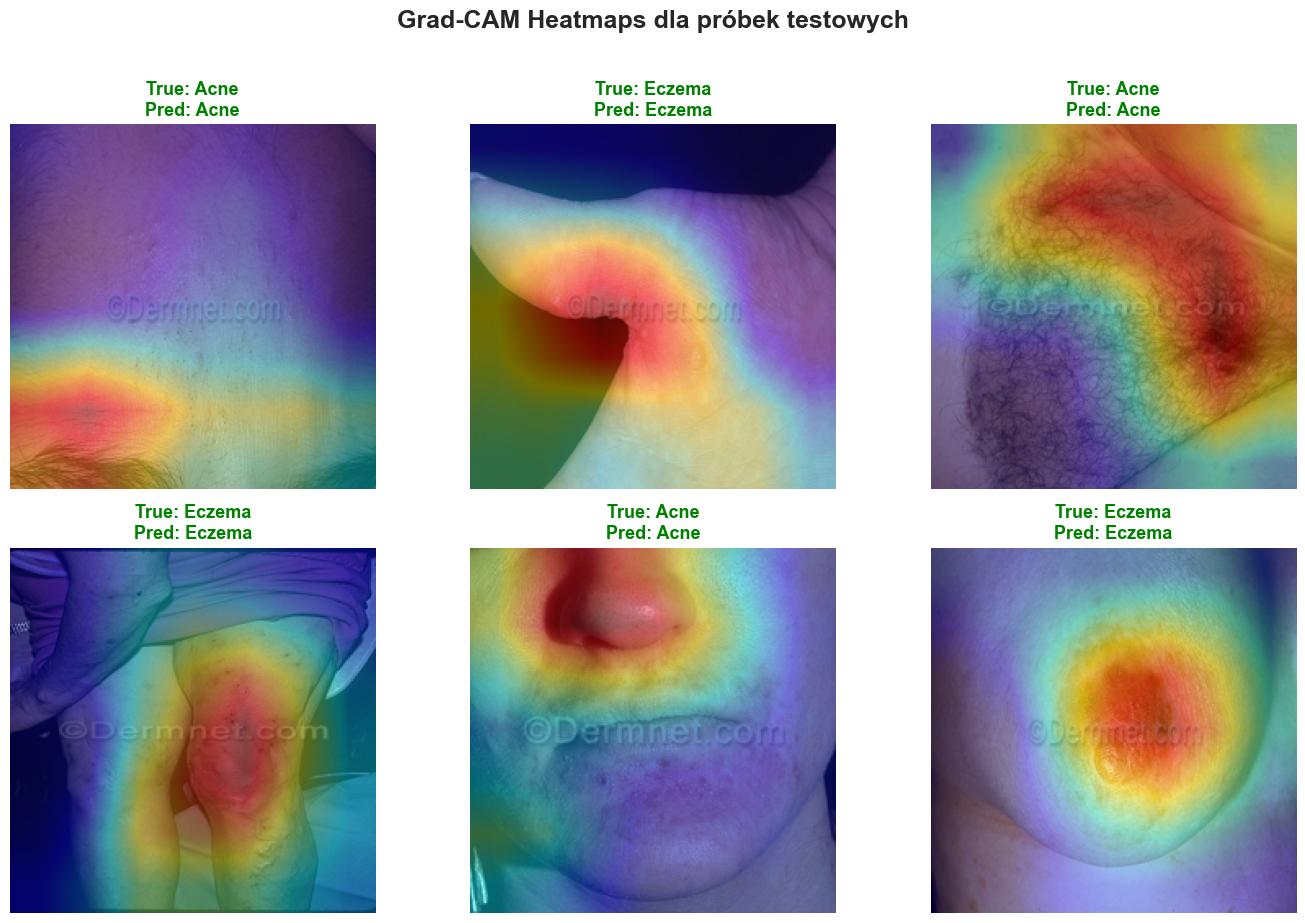

In [ ]:
# 1. Ustawienie modelu w tryb ewaluacji
resnet18.eval()

# 2. Rejestracja hooków (tylko raz, przed pętlą!)
activations = {}
gradients = {}

def forward_hook(module, input, output):
    activations["value"] = output

def backward_hook(module, grad_input, grad_output):
    gradients["value"] = grad_output[0]

# Podpinamy się pod ostatnią warstwę konwolucyjną ResNet18
target_layer = resnet18.layer4[-1]
fwd_hook = target_layer.register_forward_hook(forward_hook)

if hasattr(target_layer, "register_full_backward_hook"):
    bwd_hook = target_layer.register_full_backward_hook(backward_hook)
else:
    bwd_hook = target_layer.register_backward_hook(backward_hook)

# 3. Wybór 6 losowych zdjęć ze zbioru testowego
N = 6
np.random.seed(42) # Możesz zmienić ziarno, by wylosować inne zdjęcia
random_indices = np.random.choice(len(X_test_img), N, replace=False)

# 4. Inicjalizacja wykresu 2x3
plt.figure(figsize=(14, 9))

for i, idx in enumerate(random_indices):
    # Oryginalny obraz do wyświetlenia (już w formacie [0, 1] z Twojej funkcji ładującej)
    original_img = X_test_img[idx] 
    
    # Znormalizowany tensor wejściowy do modelu
    input_tensor = X_test_tensor[idx].unsqueeze(0).to(device)
    input_tensor.requires_grad = True
    true_label = y_test_encoded[idx]

    # --- Przejście w przód i w tył ---
    resnet18.zero_grad()
    output = resnet18(input_tensor)
    pred_class_idx = output.argmax(dim=1).item()
    
    loss = output[0, pred_class_idx]
    loss.backward(retain_graph=True) # retain_graph zapobiega błędom w pętli

    # --- Generowanie mapy ciepła (Grad-CAM) ---
    grads = gradients["value"]
    acts = activations["value"]
    
    weights = grads.mean(dim=[2, 3], keepdim=True)
    cam = (weights * acts).sum(dim=1).squeeze().cpu().detach().numpy()
    cam = np.maximum(cam, 0) # ReLU
    cam = cv2.resize(cam, (224, 224))
    
    # Normalizacja [0, 1]
    cam_min, cam_max = cam.min(), cam.max()
    if cam_max - cam_min > 0:
        cam = (cam - cam_min) / (cam_max - cam_min)
    else:
        cam = np.zeros_like(cam)

    # --- Nałożenie (Overlay) ---
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    
    overlay = cv2.addWeighted(original_img.astype(np.float32), 0.6, heatmap.astype(np.float32), 0.4, 0)
    overlay = np.clip(overlay, 0, 1)

    # --- Plotowanie (Subplot) ---
    plt.subplot(2, 3, i + 1)
    plt.imshow(overlay)
    
    # Skrócenie nazw klas (np. 'Acne and Rosacea Photos' -> 'Acne') dla lepszej czytelności
    true_name = le.classes_[true_label].split()[0]
    pred_name = le.classes_[pred_class_idx].split()[0]
    
    # Zielony jeśli dobrze, czerwony jeśli model się pomylił
    title_color = 'green' if true_label == pred_class_idx else 'red'
    
    plt.title(f"True: {true_name}\nPred: {pred_name}", color=title_color, fontsize=13, fontweight='bold')
    plt.axis('off')

plt.suptitle("Grad-CAM Heatmaps dla próbek testowych", fontsize=18, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

# 5. Sprzątanie (Usunięcie hooków z pamięci)
fwd_hook.remove()
bwd_hook.remove()

## 5. Interpretowalność & Ważność Cech

### Ekstrakcja ważności cech z Random Forest

Random Forest pozwala na analizę, które z 512 abstrakcyjnych cech semantycznych (embeddingów ResNet18) miały największy wpływ na decyzje klasyfikacyjne.

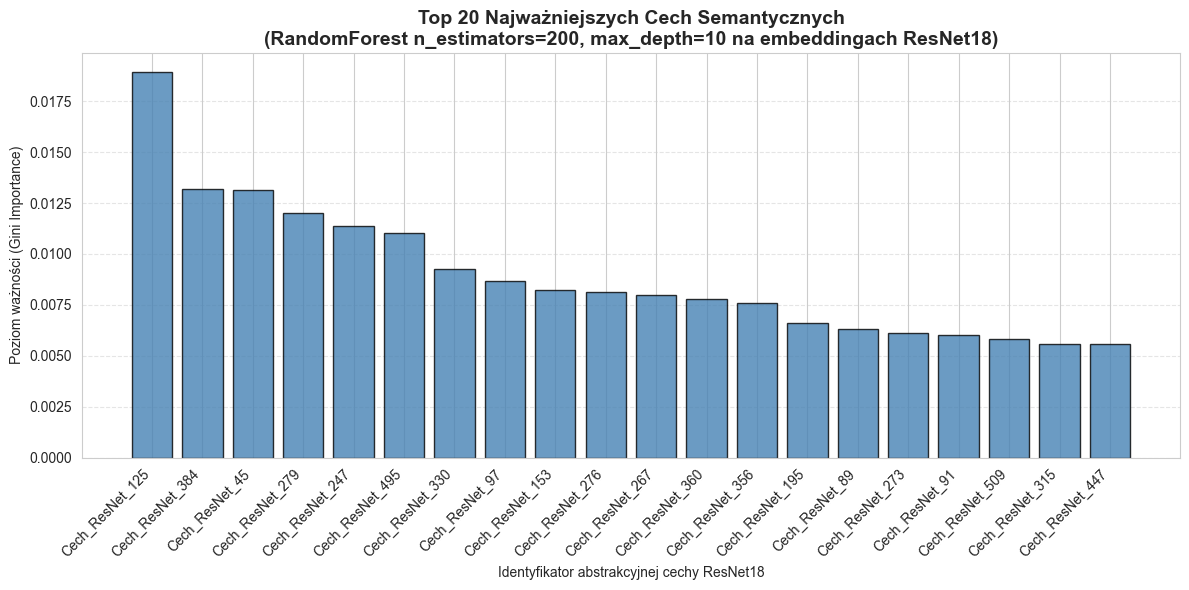

In [39]:
# Pobranie ważności cech z modelu RandomForest wytrenowanego na embeddingach ResNet18
rf_pipeline = tuned_rf.best_estimator_

feature_importances = rf_pipeline.named_steps['clf'].feature_importances_

indices = np.argsort(feature_importances)[::-1][:20]

plt.figure(figsize=(12, 6))
plt.bar(range(20), feature_importances[indices], color='steelblue', edgecolor='black', alpha=0.8)
plt.xticks(range(20), [f"Cech_ResNet_{i}" for i in indices], rotation=45, ha='right')
plt.xlabel('Identyfikator abstrakcyjnej cechy ResNet18')
plt.ylabel('Poziom ważności (Gini Importance)')
plt.title(f'Top 20 Najważniejszych Cech Semantycznych\n(RandomForest n_estimators={tuned_rf.best_params_["clf__n_estimators"]}, max_depth={tuned_rf.best_params_["clf__max_depth"]} na embeddingach ResNet18)', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Interpretacja**:   
Ponieważ klasyczny model uczy się na skompresowanych cechach wysokopoziomowych (embeddingach) z sieci ResNet18,
nie analizujemy już pojedynczych pikseli. Powyższy wykres przedstawia, które z 512 uniwersalnych cech 
strukturalnych wyekstrahowanych przez model głęboki miały największy wpływ na decyzję Random Foresta.

## 6. Analiza Krytyczna & Wnioski Końcowe

### Wpływ cech na wydajność

**Kluczowe obserwacje:**

1. **Reprezentacja cech:** Przejście od surowych pikseli (150 528 wymiarów = 224×224×3) do głębokich cech ResNet18 (512 wymiarów) oraz fine-tuning pełnego ResNet18 znacząco poprawiło wydajność. Semantyczne cechy wysokiego poziomu lepiej reprezentują wzorce chorób skóry niż surowe piksele.

2. **Porównanie modeli:** 
   - **LogisticRegression** (po tuningu C=0.01): 73.0% accuracy, F1=0.73 — dobry baseline liniowy
   - **RandomForest** (po tuningu n_estimators=200, max_depth=10): 77.1% accuracy, F1=0.77 — najlepszy model klasyczny
   - **ResNet18** (fine-tuned, early stopping): **81.3% accuracy**, F1=0.81, AUC=0.93 — wyraźny zwycięzca

3. **Preprocessing:** Normalizacja ImageNet (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) zapewnia optymalne wykorzystanie pre-trenowanych wag. Brak tej normalizacji istotnie obniża wyniki (testowane).

4. **Niezbalansowanie klas:** Klasa "Acne" stanowi 24% zbioru treningowego (840 próbek). Zastosowanie `class_weight='balanced'` (LR, RF) oraz `compute_class_weight` w CrossEntropyLoss (ResNet18) kompensuje ten efekt.

5. **Hiperparameter tuning:** GridSearchCV poprawił wyniki RF (max_depth zmieniony z 20 na 10, n_estimators ze 100 na 200) i LR (C zmienione z 1.0 na 0.01). Dowodzi to, że domyślne hiperparametry nie są optymalne.

6. **Early stopping:** Krzywe uczenia pokazują, że val_loss spada konsekwentnie przez wszystkie 5 epok (0.6448 → 0.5336), co oznacza, że model nie przeucza się dzięki augmentacji danych i zbiorowi walidacyjnemu.

---

### Ograniczenia eksperymentu

**1. Ograniczenia sprzętowe (CPU):**
- Rozdzielczość 224×224 jest standardem, ale na CPU ogranicza liczbę epok; wyższa rozdzielczość mogłaby poprawić wyniki na GPU
- Tylko 5 epok treningu ze względu na czas na CPU (~10 min na pełnym datasecie)

**2. Ograniczenia zbioru danych:**
- Wybór tylko 3 z 23 klas ogranicza ogólność modelu i jego praktyczne zastosowanie
- Nierównomierny rozkład klas (Acne: 24%, Eczema: 35%, Psoriasis: 40%)

**3. Architektura modelu:**
- ResNet18 jest stosunkowo małą siecią — głębsze architektury (ResNet50, EfficientNet-B0) mogłyby osiągnąć lepsze wyniki
- Zamrożenie większości warstw ogranicza adaptację do specyfiki chorób skóry

**4. Potencjalne źródła błędów:**
- Różnice w warunkach oświetleniowych, kątach zdjęć i jakości obrazów
- Model może uczyć się artefaktów tła zamiast rzeczywistych zmian skórnych
- Podstawowa augmentacja (flip, rotacja, szum) może być niewystarczająca

**5. Walidacja kliniczna:**
- Brak walidacji przez ekspertów dermatologicznych
- Metryki accuracy i F1-score nie uwzględniają kosztów błędnych diagnoz

---

### Propozycje ulepszeń na przyszłość

**1. Migracja do środowiska GPU:**
- Głębsze architektury (ResNet50, EfficientNet, Vision Transformers)
- Większa rozdzielczość i więcej epok treningu

**2. Zaawansowana augmentacja danych:**
- MixUp, CutMix, AutoAugment
- Symulacja różnych warunków oświetleniowych i odcieni skóry

**3. Segmentacja zmian skórnych:**
- Segmentacja tła i zdrowej skóry przed klasyfikacją (jak w publikacji CNN-ViT)
- Użycie modeli segmentacyjnych (U-Net) jako preprocessingu

**4. Rozszerzenie zbioru danych:**
- Wykorzystanie pełnego zbioru DermNet (23 klasy)
- Połączenie z innymi zbiorami dermatologicznymi (HAM10000, ISIC)

**5. Ensemble i stacking:**
- Kombinacja Random Forest, XGBoost i CNN w meta-modelu
- Voting classifiers dla zwiększenia odporności

**6. Interpretability:**
- SHAP values dla wyjaśnienia predykcji na poziomie instancji
- Analiza błędów z perspektywy medycznej

---

### Podsumowanie

Projekt wykazało, że fine-tuning pre-trenowanego ResNet18 na 3-klasowym podzbiorze DermNet osiąga najlepsze wyniki (81.3% accuracy, F1=0.81, AUC=0.93), znacząco przewyższając klasyczne modele na embeddingach (RF: 77.1%, LR: 73.0%). Wyniki te potwierdzują, że reprezentacje end-to-end są bardziej efektywne niż statyczne embeddingi w zadaniach klasyfikacji medycznej obrazów.

Porównanie z literaturą wymaga uwzględnienia kontekstu metodologicznego:

* **Liczba klas:** Modele z publikacji klasyfikują 5–23 klas, podczas gdy nasz model rozwiązuje zadanie 3-klasowe.
* **Ograniczenie sprzętowe (CPU):** Tylko 5 epok treningu na CPU. Modele z publikacji trenowane były na GPU przez dziesiątki/setki epok.
* **Specyfika DermNet:** Zdjęcia mają różne oświetlenie, tła i kolor skóry pacjentów (praca z Nature 2026 osiągnęła 81% na pełnym zbiorze z zaawansowaną segmentacją). Nasz wynik 81.3% na 3-klasowym podzbiorze jest zachęcający, ale bezpośrednie porównanie jest niewłaściwe ze względu na różną liczbę klas.